#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install pydeseq2
%pip install sanbomics
%pip install scanpy
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 10.5 MB/s eta 0:00:00


In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sanbomics.tools import id_map
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#PCA
import scanpy as sc

#GSEA
import gseapy as gp
from gseapy.plot import gseaplot

#Volcano
from sanbomics.plots import volcano

#pyDESeq2

In [4]:
counts = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF10A_PIK3CA_isogenics_RNA_seq_analysis/MCF_PI3K_featureCounts/counts_matrix_filtered_MCF_PI3K.csv')
counts = counts.rename(columns = {'Unnamed: 0' : 'gene_id'})


# #compare by excluding E5_3

counts = counts[['gene_id', 'MCF_WT_1', 'MCF_WT_2', 'MCF_WT_3',
                 'MCF_E5_1', 'MCF_E5_2',
                 'MCF_H10_1', 'MCF_H10_2', 'MCF_H10_3']]


# #compare WT vs H1047R

# counts = counts[['gene_id', 'MCF_WT_1', 'MCF_WT_2', 'MCF_WT_3',
#                  'MCF_H10_1', 'MCF_H10_2', 'MCF_H10_3']]

counts

,gene_id,MCF_WT_1,MCF_WT_2,MCF_WT_3,MCF_E5_1,MCF_E5_2,MCF_H10_1,MCF_H10_2,MCF_H10_3
0,ENSG00000227232,418,506,525,255,329,328,249,372
1,ENSG00000233750,13,39,25,14,5,17,3,13
2,ENSG00000268903,8,8,12,9,17,11,27,12
3,ENSG00000241860,5,22,13,31,19,28,11,19
4,ENSG00000279457,465,501,370,168,212,339,240,323
...,...,...,...,...,...,...,...,...,...
16150,ENSG00000182484,81,153,117,59,105,34,31,42
16151,ENSG00000231341,20,22,20,34,24,26,20,20
16152,ENSG00000235001,34,44,72,92,55,77,68,69
16153,ENSG00000215414,740,920,986,402,271,325,269,494


In [5]:
counts = counts.set_index('gene_id')
counts

,MCF_WT_1,MCF_WT_2,MCF_WT_3,MCF_E5_1,MCF_E5_2,MCF_H10_1,MCF_H10_2,MCF_H10_3
gene_id,,,,,,,,
ENSG00000227232,418,506,525,255,329,328,249,372
ENSG00000233750,13,39,25,14,5,17,3,13
ENSG00000268903,8,8,12,9,17,11,27,12
ENSG00000241860,5,22,13,31,19,28,11,19
ENSG00000279457,465,501,370,168,212,339,240,323
...,...,...,...,...,...,...,...,...
ENSG00000182484,81,153,117,59,105,34,31,42
ENSG00000231341,20,22,20,34,24,26,20,20
ENSG00000235001,34,44,72,92,55,77,68,69


In [6]:
counts = counts[counts.sum(axis = 1) > 0]
counts

,MCF_WT_1,MCF_WT_2,MCF_WT_3,MCF_E5_1,MCF_E5_2,MCF_H10_1,MCF_H10_2,MCF_H10_3
gene_id,,,,,,,,
ENSG00000227232,418,506,525,255,329,328,249,372
ENSG00000233750,13,39,25,14,5,17,3,13
ENSG00000268903,8,8,12,9,17,11,27,12
ENSG00000241860,5,22,13,31,19,28,11,19
ENSG00000279457,465,501,370,168,212,339,240,323
...,...,...,...,...,...,...,...,...
ENSG00000182484,81,153,117,59,105,34,31,42
ENSG00000231341,20,22,20,34,24,26,20,20
ENSG00000235001,34,44,72,92,55,77,68,69


In [7]:
counts = counts.T

In [8]:
counts

gene_id,ENSG00000227232,ENSG00000233750,ENSG00000268903,ENSG00000241860,ENSG00000279457,ENSG00000228463,ENSG00000236679,ENSG00000236601,ENSG00000237094,ENSG00000250575,...,ENSG00000274791,ENSG00000277150,ENSG00000185973,ENSG00000124333,ENSG00000185203,ENSG00000182484,ENSG00000231341,ENSG00000235001,ENSG00000215414,ENSG00000185275
MCF_WT_1,418,13,8,5,465,142,8,156,60,30,...,730,1200,321,1134,54,81,20,34,740,203
MCF_WT_2,506,39,8,22,501,517,37,134,58,32,...,500,866,311,974,122,153,22,44,920,143
MCF_WT_3,525,25,12,13,370,648,81,375,17,17,...,596,994,359,1312,123,117,20,72,986,263
MCF_E5_1,255,14,9,31,168,5497,77,0,31,16,...,290,499,360,1270,1,59,34,92,402,17
MCF_E5_2,329,5,17,19,212,2640,26,0,20,19,...,441,706,360,1060,0,105,24,55,271,13
MCF_H10_1,328,17,11,28,339,1169,18,5,24,20,...,415,718,515,1352,0,34,26,77,325,65
MCF_H10_2,249,3,27,11,240,1383,20,2,22,15,...,426,705,457,1121,0,31,20,68,269,61
MCF_H10_3,372,13,12,19,323,1639,26,0,38,27,...,341,505,521,1558,2,42,20,69,494,17


In [9]:
# metadata = pd.DataFrame(zip(counts.index, ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT', 'MUT', 'MUT', 'MUT']),
#                         columns = ['Sample', 'PIK3CA'])

# #For comparison without E5_3

metadata = pd.DataFrame(zip(counts.index, ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT', 'MUT', 'MUT']),
                        columns = ['Sample', 'PIK3CA'])

#For WT vs H1047R comparison
# metadata = pd.DataFrame(zip(counts.index, ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT']),
#                         columns = ['Sample', 'PIK3CA'])

In [10]:
metadata = metadata.set_index('Sample')
metadata

,PIK3CA
Sample,
MCF_WT_1,WT
MCF_WT_2,WT
MCF_WT_3,WT
MCF_E5_1,MUT
MCF_E5_2,MUT
MCF_H10_1,MUT
MCF_H10_2,MUT
MCF_H10_3,MUT


In [11]:
dds = DeseqDataSet(counts=counts,
                   metadata=metadata,
                   design_factors="PIK3CA")

/tmp/ipython-input-2678929524.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts,


In [12]:
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 19.75 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 25.02 seconds.

Fitting LFCs...
... done in 12.62 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [13]:
dds

AnnData object with n_obs × n_vars = 8 × 16155
    obs: 'PIK3CA', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [14]:
stat_res = DeseqStats(dds, contrast = ('PIK3CA','MUT','WT'))

In [15]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: PIK3CA MUT vs WT
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                         
ENSG00000227232  367.196553       -0.602786  0.190681 -3.161231  1.571038e-03   
ENSG00000233750   15.812053       -1.303042  0.663794 -1.963022  4.964360e-02   
ENSG00000268903   13.226177        0.805853  0.641281  1.256630  2.088876e-01   
ENSG00000241860   18.375039        0.715289  0.601874  1.188436  2.346618e-01   
ENSG00000279457  321.646781       -0.751381  0.248713 -3.021075  2.518791e-03   
...                     ...             ...       ...       ...           ...   
ENSG00000182484   77.279068       -1.051849  0.453548 -2.319155  2.038663e-02   
ENSG00000231341   23.117843        0.324704  0.425706  0.762742  4.456174e-01   
ENSG00000235001   63.515946        0.595413  0.339035  1.756203  7.905377e-02   
ENSG00000215414  539.830361       -1.275728  0.228469 

... done in 4.04 seconds.



In [16]:
res = stat_res.results_df

In [17]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03
ENSG00000233750,15.812053,-1.303042,0.663794,-1.963022,4.964360e-02,6.980807e-02
ENSG00000268903,13.226177,0.805853,0.641281,1.256630,2.088876e-01,2.572138e-01
ENSG00000241860,18.375039,0.715289,0.601874,1.188436,2.346618e-01,2.848229e-01
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03
...,...,...,...,...,...,...
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02
ENSG00000231341,23.117843,0.324704,0.425706,0.762742,4.456174e-01,5.029436e-01
ENSG00000235001,63.515946,0.595413,0.339035,1.756203,7.905377e-02,1.067117e-01


In [18]:
# res.to_csv('drive/My Drive/Colab Notebooks/GP_lab_data//MCF10A_PIK3CA_isogenics_RNA_seq_analysis/pyDESeq2_results/pyDESeq2_results.txt', sep = '\t')

#GSEA

In [19]:
gene_names = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/SUM149_BRCA1_DESeq2/ensembl_id_gene_name.csv')
gene_names = gene_names.rename(columns = {'gene_name' : 'Symbol'})
gene_names

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000210082,MT-RNR2
...,...,...
58730,ENSG00000276351,RF01973
58731,ENSG00000275661,RF01974
58732,ENSG00000277856,AC233755.2
58733,ENSG00000275063,AC233755.1


In [20]:
gene_names = gene_names[gene_names['gene_id'].isin(res.index)]
gene_names = gene_names.set_index('gene_id')
gene_names

,Symbol
gene_id,
ENSG00000198712,MT-CO2
ENSG00000198804,MT-CO1
ENSG00000198938,MT-CO3
ENSG00000198899,MT-ATP6
ENSG00000210082,MT-RNR2
...,...
ENSG00000100362,PVALB
ENSG00000219438,FAM19A5
ENSG00000279064,FP236315.1


In [21]:
res1 = pd.concat([gene_names, res], axis = 'columns')
res1.head(3)

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,,
ENSG00000198712,MT-CO2,981564.815633,-1.915744,0.287735,-6.658018,2.775455e-11,1.196693e-10
ENSG00000198804,MT-CO1,229219.277972,-1.271061,0.405771,-3.132456,1.733506e-03,3.076854e-03
ENSG00000198938,MT-CO3,423111.994618,-1.730823,0.261539,-6.617848,3.644664e-11,1.556503e-10


In [22]:
res1.sort_values(by = 'log2FoldChange', ascending = False)

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,,
ENSG00000264230,ANXA8L1,17656.946424,14.424559,0.789996,18.259020,1.754106e-74,9.253771e-73
ENSG00000106366,SERPINE1,12700.158427,14.341764,1.325504,10.819854,2.772187e-27,3.167120e-26
ENSG00000196636,SDHAF3,1905.160463,14.070661,1.958662,7.183813,6.779335e-13,3.378784e-12
ENSG00000233532,LINC00460,1839.318253,14.019888,1.958807,7.157359,8.224584e-13,4.066446e-12
ENSG00000177494,ZBED2,1536.692007,13.760471,1.953999,7.042208,1.892164e-12,9.088130e-12
...,...,...,...,...,...,...,...
ENSG00000260228,AC009119.1,778.220926,-12.872940,1.244746,-10.341818,4.558052e-25,4.713686e-24
ENSG00000165140,FBP1,3444.989386,-13.119928,1.559393,-8.413485,3.980065e-17,2.687168e-16
ENSG00000152137,HSPB8,1020.954115,-13.264743,1.276138,-10.394444,2.628154e-25,2.758537e-24


In [23]:
res1[res1['Symbol'] == 'CAD']

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,,
ENSG00000084774,CAD,494.916269,0.902651,0.2422,3.726883,0.000194,0.000392


In [24]:
ranking = res1[['Symbol', 'stat']].dropna().sort_values('stat', ascending = False)
ranking

,Symbol,stat
gene_id,,
ENSG00000205426,KRT81,78.991759
ENSG00000196754,S100A2,73.309438
ENSG00000205420,KRT6A,57.184245
ENSG00000084207,GSTP1,51.676702
ENSG00000128422,KRT17,49.087596
...,...,...
ENSG00000131748,STARD3,-36.880164
ENSG00000141736,ERBB2,-37.976657
ENSG00000132746,ALDH3B2,-39.721293


In [25]:
ranking = ranking.drop_duplicates('Symbol')

In [26]:
ranking

,Symbol,stat
gene_id,,
ENSG00000205426,KRT81,78.991759
ENSG00000196754,S100A2,73.309438
ENSG00000205420,KRT6A,57.184245
ENSG00000084207,GSTP1,51.676702
ENSG00000128422,KRT17,49.087596
...,...,...
ENSG00000131748,STARD3,-36.880164
ENSG00000141736,ERBB2,-37.976657
ENSG00000132746,ALDH3B2,-39.721293


In [27]:
ranking = ranking.set_index('Symbol')
ranking

,stat
Symbol,
KRT81,78.991759
S100A2,73.309438
KRT6A,57.184245
GSTP1,51.676702
KRT17,49.087596
...,...
STARD3,-36.880164
ERBB2,-37.976657
ALDH3B2,-39.721293


In [28]:
gp.get_library_name() #to look at available libraries

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [29]:
pre_res = gp.prerank(rnk = ranking, gene_sets = 'KEGG_2021_Human', seed = 6, permutation_num = 100)

In [30]:
out = []

for term in list(pre_res.results):
    out.append([term,
               pre_res.results[term]['fdr'],
               pre_res.results[term]['es'],
               pre_res.results[term]['nes']])

out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
out_df

,Term,fdr,es,nes
0,Ribosome,0.000000,0.541124,2.249374
1,Coronavirus disease,0.000000,0.509311,2.261227
2,ECM-receptor interaction,0.000000,0.680244,2.435313
3,Focal adhesion,0.000000,0.505461,2.212095
4,Complement and coagulation cascades,0.000000,0.601569,2.029174
...,...,...,...,...
282,Vitamin digestion and absorption,0.968625,-0.257690,-0.742129
283,DNA replication,0.970188,-0.192368,-0.661775
284,mRNA surveillance pathway,0.971607,-0.172201,-0.714620
285,Mismatch repair,0.975407,-0.231395,-0.694138


In [31]:
import string

kegg_metabolic_pathways = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF10A_PIK3CA_isogenics_RNA_seq_analysis/MCF_PI3K_featureCounts/KEGG_metabolic_pathways.csv')
kegg_metabolic_pathways = kegg_metabolic_pathways[['1. Metabolism']].dropna()
kegg_metabolic_pathways

list_kegg_mp = []
for i in kegg_metabolic_pathways['1. Metabolism']:
  if i[0].isdigit():
    pass
  else:
    list_kegg_mp.append(i)
list_kegg_mp

['Metabolic pathways',
 'Biosynthesis of secondary metabolites',
 'Microbial metabolism in diverse environments',
 'Carbon metabolism',
 'Fatty acid metabolism',
 'Biosynthesis of amino acids',
 'Nucleotide metabolism',
 'Biosynthesis of nucleotide sugars',
 'Biosynthesis of cofactors',
 'Degradation of aromatic compounds',
 'Glycolysis / Gluconeogenesis',
 'Citrate cycle (TCA cycle)',
 'Pentose phosphate pathway',
 'Pentose and glucuronate interconversions',
 'Fructose and mannose metabolism',
 'Galactose metabolism',
 'Ascorbate and aldarate metabolism',
 'Starch and sucrose metabolism',
 'Amino sugar and nucleotide sugar metabolism',
 'Pyruvate metabolism',
 'Glyoxylate and dicarboxylate metabolism',
 'Propanoate metabolism',
 'Butanoate metabolism',
 'C5-Branched dibasic acid metabolism',
 'Inositol phosphate metabolism',
 'Oxidative phosphorylation',
 'Photosynthesis',
 'Photosynthesis - antenna proteins',
 'Carbon fixation in photosynthetic organisms',
 'Carbon fixation pathways 

In [32]:
metabolic_out_df = out_df[out_df['Term'].isin(list_kegg_mp)]
metabolic_out_df = metabolic_out_df.sort_values('nes', ascending = True)
metabolic_out_df

,Term,fdr,es,nes
79,"Valine, leucine and isoleucine degradation",0.110977,-0.467908,-1.690427
140,Biosynthesis of unsaturated fatty acids,0.331265,-0.504051,-1.536132
144,Glycosylphosphatidylinositol (GPI)-anchor bios...,0.351954,-0.469727,-1.458651
178,Tyrosine metabolism,0.450565,-0.489567,-1.393996
173,Oxidative phosphorylation,0.432203,-0.338305,-1.370620
166,Citrate cycle (TCA cycle),0.415052,-0.420404,-1.366293
147,Propanoate metabolism,0.364320,-0.416670,-1.361098
165,Pyruvate metabolism,0.411723,-0.386032,-1.305944
148,beta-Alanine metabolism,0.367174,-0.435218,-1.300598
181,"Glycine, serine and threonine metabolism",0.473826,-0.390902,-1.232362


<Axes: title={'center': 'KEGG metabolic pathways'}, xlabel='nes', ylabel='Term'>

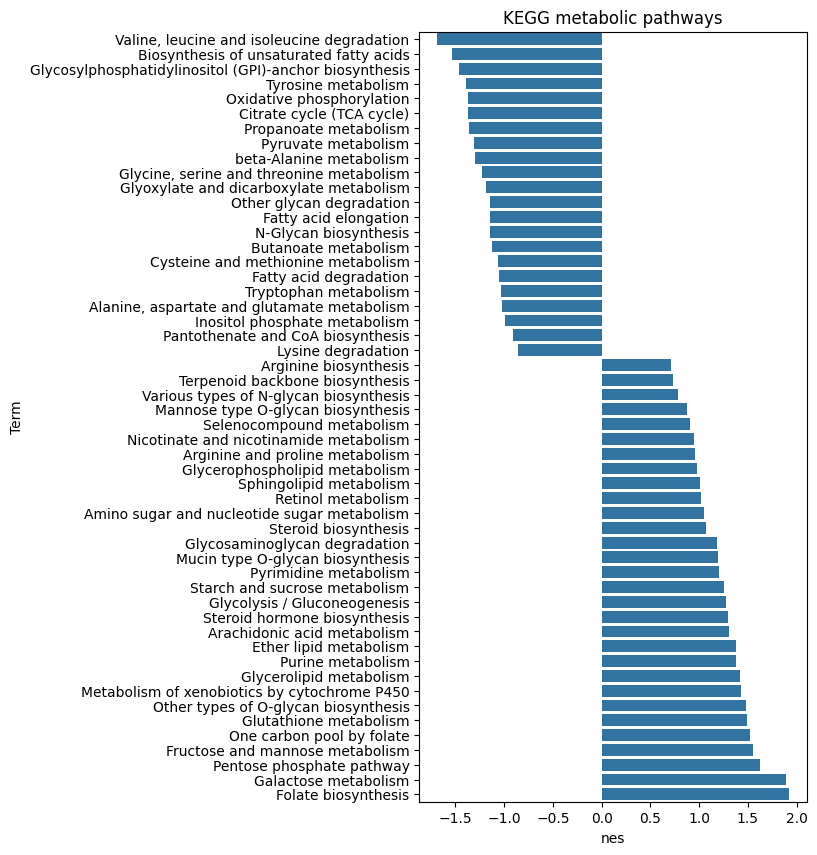

In [33]:
plt.figure(figsize = (5,10))
plt.title('KEGG metabolic pathways')
sns.barplot(data = metabolic_out_df,
            x = 'nes',
            y = 'Term')

In [34]:
pre_res.res2d.sort_values('NES').head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
14,prerank,Herpes simplex virus 1 infection,-0.361295,-1.851312,0.0,0.066586,0.1,182/406,28.23%,PIK3R3;ZNF425;ZNF443;ZNF823;ZNF347;ZNF136;NECT...
29,prerank,Insulin secretion,-0.454369,-1.712261,0.0,0.109867,0.28,20/49,20.33%,CREB3L4;CAMK2D;GNAS;ATP1B1;PLCB4;RIMS2;CREB3L1...
33,prerank,"Valine, leucine and isoleucine degradation",-0.467908,-1.690427,0.019231,0.110977,0.38,14/42,10.10%,PCCB;MCCC1;PCCA;ALDH6A1;HIBADH;ALDH2;HMGCS2;AB...
58,prerank,Biosynthesis of unsaturated fatty acids,-0.504051,-1.536132,0.075472,0.331265,0.79,5/24,4.03%,FADS2;ACOT1;ACOT2;ACOT4;ELOVL5
60,prerank,Cortisol synthesis and secretion,-0.419727,-1.525672,0.0,0.298305,0.83,11/41,15.31%,CREB3L4;PBX1;GNAS;NR4A1;PLCB4;CREB3L1;ADCY6;AD...


In [35]:
gsea_data_set = pre_res.res2d.sort_values('NES')
gsea_data_set

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
14,prerank,Herpes simplex virus 1 infection,-0.361295,-1.851312,0.0,0.066586,0.1,182/406,28.23%,PIK3R3;ZNF425;ZNF443;ZNF823;ZNF347;ZNF136;NECT...
29,prerank,Insulin secretion,-0.454369,-1.712261,0.0,0.109867,0.28,20/49,20.33%,CREB3L4;CAMK2D;GNAS;ATP1B1;PLCB4;RIMS2;CREB3L1...
33,prerank,"Valine, leucine and isoleucine degradation",-0.467908,-1.690427,0.019231,0.110977,0.38,14/42,10.10%,PCCB;MCCC1;PCCA;ALDH6A1;HIBADH;ALDH2;HMGCS2;AB...
58,prerank,Biosynthesis of unsaturated fatty acids,-0.504051,-1.536132,0.075472,0.331265,0.79,5/24,4.03%,FADS2;ACOT1;ACOT2;ACOT4;ELOVL5
60,prerank,Cortisol synthesis and secretion,-0.419727,-1.525672,0.0,0.298305,0.83,11/41,15.31%,CREB3L4;PBX1;GNAS;NR4A1;PLCB4;CREB3L1;ADCY6;AD...
...,...,...,...,...,...,...,...,...,...,...
4,prerank,Complement and coagulation cascades,0.601569,2.029174,0.0,0.0,0.0,14/37,12.48%,F3;F12;PROCR;TFPI;PLAU;THBD;CD59;PLAUR;SERPINE...
3,prerank,Focal adhesion,0.505461,2.212095,0.0,0.0,0.0,56/149,12.99%,CAV1;CAV2;ITGB4;LAMB3;SHC1;ITGA6;ITGA5;EGFR;IT...
2,prerank,Ribosome,0.541124,2.249374,0.0,0.0,0.0,74/127,23.54%,RPS23;RPL22L1;RPSA;RPL18A;RPS8;RPL14;RPL5;RPL2...
1,prerank,Coronavirus disease,0.509311,2.261227,0.0,0.0,0.0,78/163,19.52%,RPS23;EGFR;FOS;RPL22L1;RPSA;RPL18A;RPS8;RPL14;...


In [36]:
pyrimidine_gene_sig = gsea_data_set[gsea_data_set['Term'] == 'Pyrimidine metabolism']['Lead_genes'].iloc[0]
pyrimidine_gene_sig = pyrimidine_gene_sig.split(';')
pyrimidine_gene_sig

['NT5E', 'TYMP', 'DCTD', 'UPP1', 'CDA', 'CTPS1', 'PNP', 'DPYD', 'UCK2', 'NME7']

In [37]:
purine_gene_sig = gsea_data_set[gsea_data_set['Term'] == 'Purine metabolism']['Lead_genes'].iloc[0]
purine_gene_sig = purine_gene_sig.split(';')
purine_gene_sig

['NT5E',
 'PGM1',
 'AMPD2',
 'XDH',
 'PDE4D',
 'PGM2',
 'PRPS1',
 'AK2',
 'HPRT1',
 'GUCY1B1',
 'AK3',
 'PNP',
 'NTPCR',
 'ADCY3',
 'ADCY7',
 'IMPDH2',
 'GART',
 'NME7',
 'FHIT',
 'AK4']

In [38]:
selected_processess = pd.concat([gsea_data_set.head(10), gsea_data_set.tail(10)], axis = 'index')
selected_processess

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
14,prerank,Herpes simplex virus 1 infection,-0.361295,-1.851312,0.0,0.066586,0.1,182/406,28.23%,PIK3R3;ZNF425;ZNF443;ZNF823;ZNF347;ZNF136;NECT...
29,prerank,Insulin secretion,-0.454369,-1.712261,0.0,0.109867,0.28,20/49,20.33%,CREB3L4;CAMK2D;GNAS;ATP1B1;PLCB4;RIMS2;CREB3L1...
33,prerank,"Valine, leucine and isoleucine degradation",-0.467908,-1.690427,0.019231,0.110977,0.38,14/42,10.10%,PCCB;MCCC1;PCCA;ALDH6A1;HIBADH;ALDH2;HMGCS2;AB...
58,prerank,Biosynthesis of unsaturated fatty acids,-0.504051,-1.536132,0.075472,0.331265,0.79,5/24,4.03%,FADS2;ACOT1;ACOT2;ACOT4;ELOVL5
60,prerank,Cortisol synthesis and secretion,-0.419727,-1.525672,0.0,0.298305,0.83,11/41,15.31%,CREB3L4;PBX1;GNAS;NR4A1;PLCB4;CREB3L1;ADCY6;AD...
75,prerank,Collecting duct acid secretion,-0.49761,-1.461582,0.075472,0.398406,0.95,10/21,30.08%,ATP6V0E2;SLC12A7;ATP6V0A4;ATP6V1G2;ATP6V1G1;AT...
76,prerank,Glycosylphosphatidylinositol (GPI)-anchor bios...,-0.469727,-1.458651,0.078947,0.351954,0.96,9/25,13.67%,PIGU;PIGO;PIGX;PIGT;PIGM;MPPE1;DPM2;PIGS;PIGZ
86,prerank,Synaptic vesicle cycle,-0.382128,-1.39581,0.076923,0.500227,1.0,19/50,25.61%,ATP6V0E2;STX3;UNC13B;CLTC;ATP6V0A4;NSF;DNM2;VA...
88,prerank,Tyrosine metabolism,-0.489567,-1.393996,0.111111,0.450565,1.0,9/20,19.83%,ALDH3B2;HGD;PNMT;GSTZ1;COMT;TH;HPD;LRTOMT;TPO
89,prerank,Endocrine and other factor-regulated calcium r...,-0.414419,-1.392786,0.071429,0.407506,1.0,7/33,9.28%,GNAS;ATP1B1;CLTC;ESR1;PLCB4;DNM2;ADCY6


<Axes: title={'center': 'KEGG all pathways (Top 10 up/down)'}, xlabel='NES', ylabel='Term'>

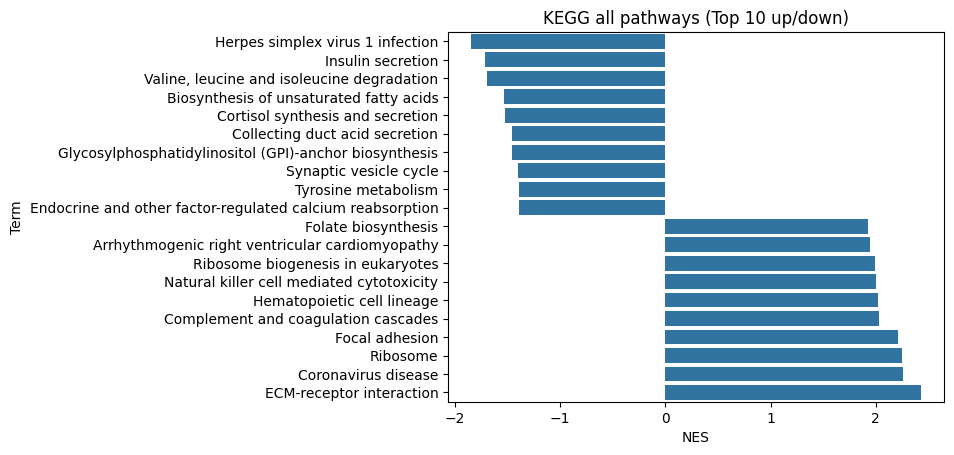

In [39]:
plt.title('KEGG all pathways (Top 10 up/down)')
sns.barplot(data = selected_processess,
            x = 'NES',
            y = 'Term')

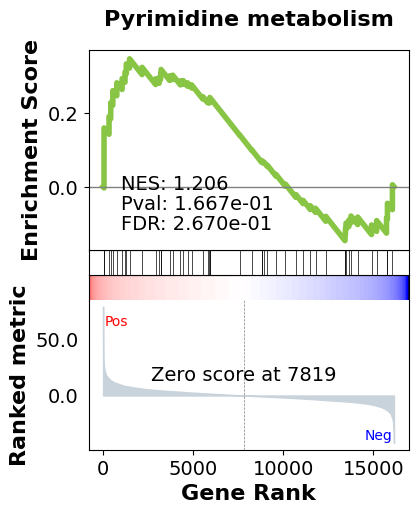

In [40]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms='Pyrimidine metabolism')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/mcf10a_pyrimidine_gsea.svg', bbox_inches = 'tight')

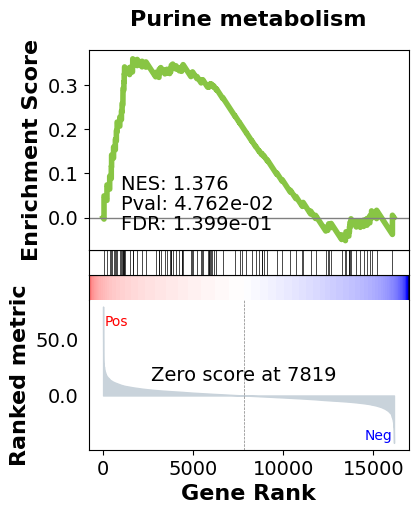

In [41]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms='Purine metabolism')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/mcf10a_purine_gsea.svg', bbox_inches = 'tight')

#DESeq2 visualization

In [42]:
mapper = id_map(species = 'human')
res['Symbol'] = res.index.map(mapper.mapper)

In [43]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03,WASH7P
ENSG00000233750,15.812053,-1.303042,0.663794,-1.963022,4.964360e-02,6.980807e-02,CICP27
ENSG00000268903,13.226177,0.805853,0.641281,1.256630,2.088876e-01,2.572138e-01,NaN
ENSG00000241860,18.375039,0.715289,0.601874,1.188436,2.346618e-01,2.848229e-01,AL627309.5
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03,WASH9P
...,...,...,...,...,...,...,...
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02,WASH6P
ENSG00000231341,23.117843,0.324704,0.425706,0.762742,4.456174e-01,5.029436e-01,VDAC1P6
ENSG00000235001,63.515946,0.595413,0.339035,1.756203,7.905377e-02,1.067117e-01,EIF4A1P2


In [44]:
res = res[res.baseMean >= 10]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03,WASH7P
ENSG00000233750,15.812053,-1.303042,0.663794,-1.963022,4.964360e-02,6.980807e-02,CICP27
ENSG00000268903,13.226177,0.805853,0.641281,1.256630,2.088876e-01,2.572138e-01,NaN
ENSG00000241860,18.375039,0.715289,0.601874,1.188436,2.346618e-01,2.848229e-01,AL627309.5
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03,WASH9P
...,...,...,...,...,...,...,...
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02,WASH6P
ENSG00000231341,23.117843,0.324704,0.425706,0.762742,4.456174e-01,5.029436e-01,VDAC1P6
ENSG00000235001,63.515946,0.595413,0.339035,1.756203,7.905377e-02,1.067117e-01,EIF4A1P2


In [45]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03,WASH7P
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03,WASH9P
ENSG00000228463,1725.440028,2.560899,0.709240,3.610765,3.052956e-04,6.018301e-04,NaN
ENSG00000236601,80.139282,-7.252928,1.131202,-6.411698,1.439080e-10,5.866430e-10,AL732372.1
ENSG00000225630,2103.286613,-1.172031,0.358679,-3.267635,1.084500e-03,1.979504e-03,MTND2P28
...,...,...,...,...,...,...,...
ENSG00000277150,763.941078,-0.621637,0.215244,-2.888050,3.876380e-03,6.569011e-03,F8A3
ENSG00000185203,36.788469,-7.336501,0.970438,-7.559985,4.031155e-14,2.207426e-13,WASIR1
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02,WASH6P


In [46]:
dds

AnnData object with n_obs × n_vars = 8 × 16155
    obs: 'PIK3CA', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [47]:
sc.tl.pca(dds)

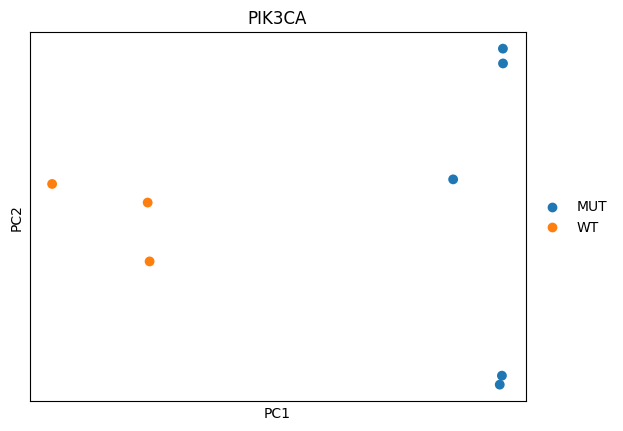

In [48]:
sc.pl.pca(dds, color = 'PIK3CA', size = 200)

In [49]:
dds.layers['normed_counts']

array([[384.35144097,  11.95351371,   7.35600844, ...,  31.26303587,
        680.43078067, 186.65871416],
       [523.63017992,  40.35884786,   8.27873802, ...,  45.53305912,
        952.05487258, 147.98244215],
       [493.00355476,  23.47635975,  11.26865268, ...,  67.61191608,
        925.90762856, 246.97130458],
       ...,
       [301.18924899,  15.61041839,  10.10085896, ...,  70.70601272,
        298.43446927,  59.68689385],
       [282.1834784 ,   3.39980094,  30.5982085 , ...,  77.06215474,
        304.84881803,  69.12928587],
       [350.38446356,  12.24461835,  11.30272463, ...,  64.99066663,
        465.29549731,  16.01219323]])

In [50]:
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])

In [51]:
dds.layers['log1p']

array([[5.95415575, 2.56136708, 2.12298085, ..., 3.47392217, 6.52419468,
        5.23462496],
       [6.2626936 , 3.72228637, 2.22772555, ..., 3.84016301, 6.85967248,
        5.00382846],
       [6.20254271, 3.19770774, 2.50704745, ..., 4.22846622, 6.83185392,
        5.51331303],
       ...,
       [5.71105347, 2.81003011, 2.40702249, ..., 4.2725746 , 5.70189559,
        4.10572776],
       [5.64609502, 1.4815593 , 3.45310043, ..., 4.35750537, 5.72309092,
        4.25034048],
       [5.86188096, 2.58359131, 2.50982075, ..., 4.18951332, 6.14481955,
        2.83393034]])

In [52]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03,WASH7P
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03,WASH9P
ENSG00000228463,1725.440028,2.560899,0.709240,3.610765,3.052956e-04,6.018301e-04,NaN
ENSG00000236601,80.139282,-7.252928,1.131202,-6.411698,1.439080e-10,5.866430e-10,AL732372.1
ENSG00000225630,2103.286613,-1.172031,0.358679,-3.267635,1.084500e-03,1.979504e-03,MTND2P28
...,...,...,...,...,...,...,...
ENSG00000277150,763.941078,-0.621637,0.215244,-2.888050,3.876380e-03,6.569011e-03,F8A3
ENSG00000185203,36.788469,-7.336501,0.970438,-7.559985,4.031155e-14,2.207426e-13,WASIR1
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02,WASH6P


In [53]:
dds_sigs = dds[:, sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 8 × 10420
    obs: 'PIK3CA', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'PIK3CA_colors'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals', 'X_pca'
    varm: 'LFC', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [54]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


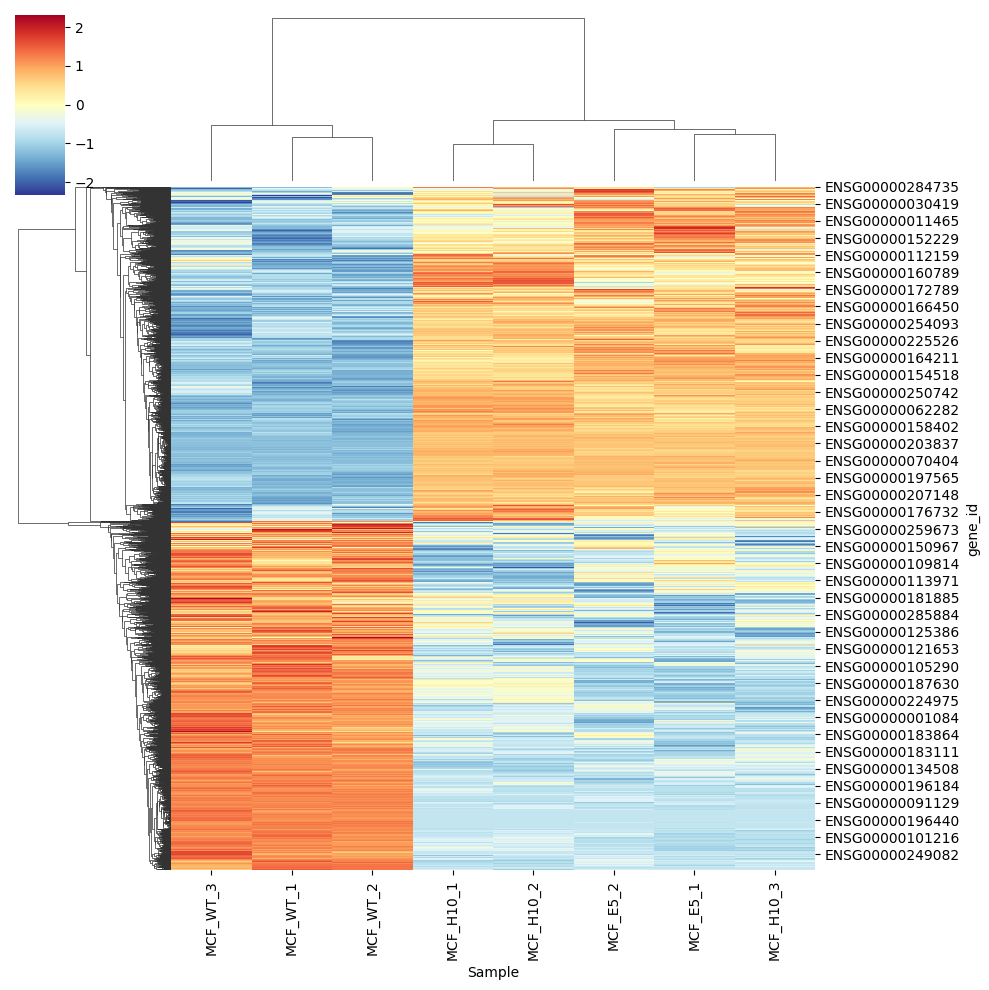

In [55]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')

In [56]:
sigs[sigs.Symbol.isin(purine_gene_sig)].index

Index(['ENSG00000004455', 'ENSG00000079739', 'ENSG00000162433',
       'ENSG00000116337', 'ENSG00000143156', 'ENSG00000135778',
       'ENSG00000138031', 'ENSG00000158125', 'ENSG00000178035',
       'ENSG00000189283', 'ENSG00000169299', 'ENSG00000061918',
       'ENSG00000113448', 'ENSG00000135318', 'ENSG00000147853',
       'ENSG00000198805', 'ENSG00000121281', 'ENSG00000159131',
       'ENSG00000147224', 'ENSG00000165704'],
      dtype='object', name='gene_id')

In [57]:
dds_sub = dds[:, sigs[sigs.Symbol.isin(purine_gene_sig)].index]

In [58]:
dds_sub

View of AnnData object with n_obs × n_vars = 8 × 20
    obs: 'PIK3CA', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'PIK3CA_colors'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals', 'X_pca'
    varm: 'LFC', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [59]:
grapher = pd.DataFrame(dds_sub.layers['log1p'].T,
                       index=dds_sub.var_names, columns=dds_sub.obs_names)

In [60]:
grapher.index = grapher.index.map(mapper.mapper)

In [61]:
grapher

Sample,MCF_WT_1,MCF_WT_2,MCF_WT_3,MCF_E5_1,MCF_E5_2,MCF_H10_1,MCF_H10_2,MCF_H10_3
gene_id,,,,,,,,
AK2,9.377260,9.316069,9.365956,10.135452,10.088715,10.084343,10.136768,10.160552
PGM1,6.454342,6.230625,6.349043,7.941120,7.994353,8.076696,8.168409,8.052084
AK4,7.693067,7.526433,7.308648,8.234304,8.390619,8.433135,8.300619,8.393125
AMPD2,2.408252,2.596605,1.559453,5.513432,5.972989,5.987975,5.880475,5.692906
NME7,6.678907,6.827677,6.577079,7.641917,7.432433,7.639653,7.782332,7.529504
NTPCR,6.786220,6.539983,6.757205,7.954056,8.002424,7.840999,7.712355,8.255474
ADCY3,4.060599,3.925382,3.522438,5.529693,5.490067,5.612117,5.962492,5.382822
XDH,0.652065,1.636930,1.739636,5.918919,5.688809,6.423627,6.286064,5.963734
IMPDH2,8.367789,8.166064,8.303504,9.219644,9.242080,9.010226,9.084144,9.128443


Text(0.5, 1.0, 'Pyrimidine metabolism genes')

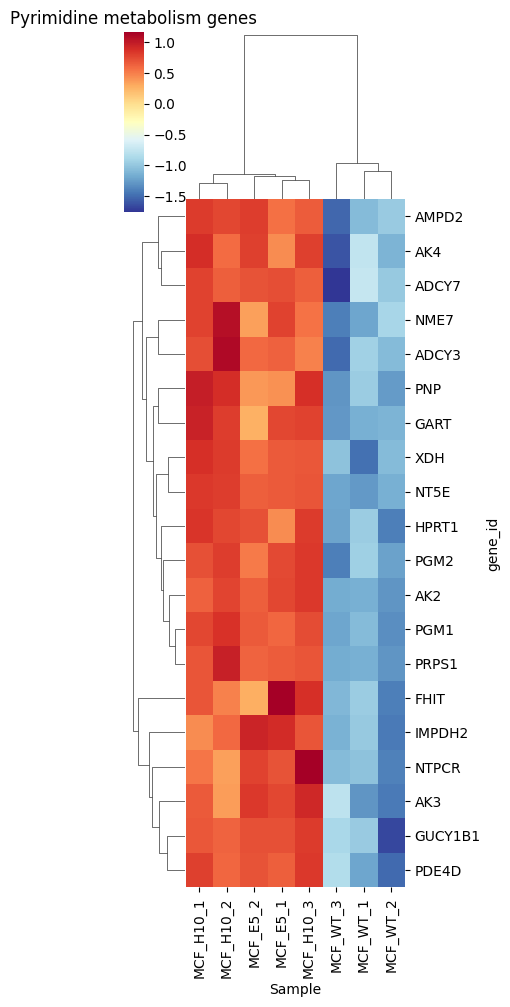

In [62]:
ax = sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r', figsize=(4,10))
plt.title('Pyrimidine metabolism genes')

In [63]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,367.196553,-0.602786,0.190681,-3.161231,1.571038e-03,2.804830e-03,WASH7P
ENSG00000233750,15.812053,-1.303042,0.663794,-1.963022,4.964360e-02,6.980807e-02,CICP27
ENSG00000268903,13.226177,0.805853,0.641281,1.256630,2.088876e-01,2.572138e-01,NaN
ENSG00000241860,18.375039,0.715289,0.601874,1.188436,2.346618e-01,2.848229e-01,AL627309.5
ENSG00000279457,321.646781,-0.751381,0.248713,-3.021075,2.518791e-03,4.371193e-03,WASH9P
...,...,...,...,...,...,...,...
ENSG00000182484,77.279068,-1.051849,0.453548,-2.319155,2.038663e-02,3.074565e-02,WASH6P
ENSG00000231341,23.117843,0.324704,0.425706,0.762742,4.456174e-01,5.029436e-01,VDAC1P6
ENSG00000235001,63.515946,0.595413,0.339035,1.756203,7.905377e-02,1.067117e-01,EIF4A1P2


0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


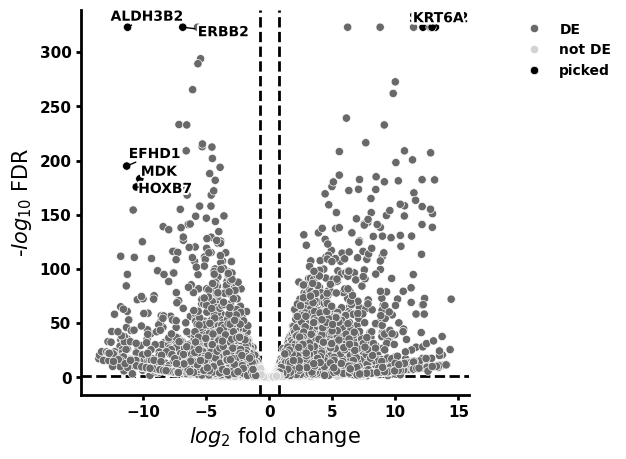

In [64]:
volcano(res, symbol='Symbol')

In [65]:
grapher.index

Index(['AK2', 'PGM1', 'AK4', 'AMPD2', 'NME7', 'NTPCR', 'ADCY3', 'XDH',
       'IMPDH2', 'FHIT', 'PGM2', 'GUCY1B1', 'PDE4D', 'NT5E', 'AK3', 'PNP',
       'ADCY7', 'GART', 'PRPS1', 'HPRT1'],
      dtype='object', name='gene_id')

0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


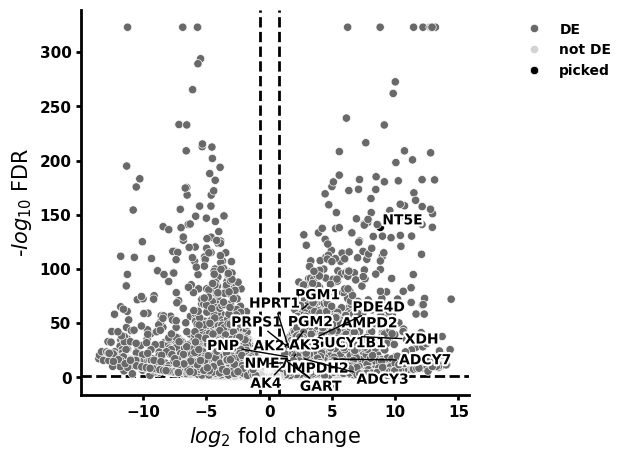

In [66]:
volcano(res, symbol='Symbol', to_label = grapher.index)